#Baseline Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Use small subset to force overfitting
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

# Simple large model to show overfitting
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model and store history
history = model.fit(X_train_small, y_train_small,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Loop through each epoch and print overfitting info
for epoch in range(len(history.history['accuracy'])):
    train_acc = history.history['accuracy'][epoch]
    val_acc = history.history['val_accuracy'][epoch]
    diff = train_acc - val_acc

    print(f"Epoch {epoch+1}")
    print("Training Accuracy:", round(train_acc, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Difference:", round(diff, 4))

    if diff > 0.05:
        print("Overfitting: YES")
    else:
        print("Overfitting: NO")

    print("-" * 40)

Epoch 1
Training Accuracy: 0.844
Validation Accuracy: 0.913
Difference: -0.069
Overfitting: NO
----------------------------------------
Epoch 2
Training Accuracy: 0.9442
Validation Accuracy: 0.923
Difference: 0.0213
Overfitting: NO
----------------------------------------
Epoch 3
Training Accuracy: 0.9675
Validation Accuracy: 0.925
Difference: 0.0425
Overfitting: NO
----------------------------------------
Epoch 4
Training Accuracy: 0.979
Validation Accuracy: 0.927
Difference: 0.052
Overfitting: YES
----------------------------------------
Epoch 5
Training Accuracy: 0.9893
Validation Accuracy: 0.937
Difference: 0.0523
Overfitting: YES
----------------------------------------
Epoch 6
Training Accuracy: 0.9973
Validation Accuracy: 0.945
Difference: 0.0523
Overfitting: YES
----------------------------------------
Epoch 7
Training Accuracy: 0.9992
Validation Accuracy: 0.941
Difference: 0.0583
Overfitting: YES
----------------------------------------
Epoch 8
Training Accuracy: 0.9998
Valida

#Apply Dropout

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Small subset to force overfitting (dropout will reduce it)
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

# Model with DROPOUT
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.3),               # Drop 30%
    Dense(256, activation='relu'),
    Dropout(0.3),               # Drop another 30%
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train_small, y_train_small,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Print per-epoch results
for epoch in range(len(history.history['accuracy'])):
    train_acc = history.history['accuracy'][epoch]
    val_acc = history.history['val_accuracy'][epoch]
    diff = train_acc - val_acc

    print(f"Epoch {epoch+1}")
    print("Training Accuracy:", round(train_acc, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Difference:", round(diff, 4))

    # Overfitting condition
    if diff > 0.05:
        print("Overfitting: YES")
    else:
        print("Overfitting: NO")

    print("-" * 40)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1
Training Accuracy: 0.7788
Validation Accuracy: 0.908
Difference: -0.1292
Overfitting: NO
----------------------------------------
Epoch 2
Training Accuracy: 0.9147
Validation Accuracy: 0.919
Difference: -0.0043
Overfitting: NO
----------------------------------------
Epoch 3
Training Accuracy: 0.9335
Validation Accuracy: 0.93
Difference: 0.0035
Overfitting: NO
----------------------------------------
Epoch 4
Training Accuracy: 0.9592
Validation Accuracy: 0.935
Difference: 0.0242
Overfitting: NO
----------------------------------------
Epoch 5
Training Accuracy: 0.964
Validation Accuracy: 0.927
Difference: 0.037
Overfitting: NO
----------------------------------------
Epoch 6
Training Accuracy: 0.9747
Validation Accuracy: 0.94
Difference: 0.0347
Overfitting: NO
----------------------------------------
Epoch 7
Training Accuracy: 0.9803
Validation Accuracy: 0.927
Difference: 0.0533
Overfitting: YES
----------------------------------------
Epoch 8
Training Accuracy: 0.978
Validatio

#Apply L2 Regularization

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.regularizers import l2

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Small subset to force overfitting (L2 will reduce it)
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

# Model with L2 Regularization
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train_small, y_train_small,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Print per-epoch results
for epoch in range(len(history.history['accuracy'])):
    train_acc = history.history['accuracy'][epoch]
    val_acc = history.history['val_accuracy'][epoch]
    diff = train_acc - val_acc

    print(f"Epoch {epoch+1}")
    print("Training Accuracy:", round(train_acc, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Difference:", round(diff, 4))

    # Overfitting detection
    if diff > 0.05:
        print("Overfitting: YES")
    else:
        print("Overfitting: NO")

    print("-" * 40)

Epoch 1
Training Accuracy: 0.831
Validation Accuracy: 0.917
Difference: -0.086
Overfitting: NO
----------------------------------------
Epoch 2
Training Accuracy: 0.938
Validation Accuracy: 0.917
Difference: 0.021
Overfitting: NO
----------------------------------------
Epoch 3
Training Accuracy: 0.956
Validation Accuracy: 0.924
Difference: 0.032
Overfitting: NO
----------------------------------------
Epoch 4
Training Accuracy: 0.9663
Validation Accuracy: 0.929
Difference: 0.0372
Overfitting: NO
----------------------------------------
Epoch 5
Training Accuracy: 0.9732
Validation Accuracy: 0.924
Difference: 0.0492
Overfitting: NO
----------------------------------------
Epoch 6
Training Accuracy: 0.982
Validation Accuracy: 0.93
Difference: 0.052
Overfitting: YES
----------------------------------------
Epoch 7
Training Accuracy: 0.9843
Validation Accuracy: 0.933
Difference: 0.0512
Overfitting: YES
----------------------------------------
Epoch 8
Training Accuracy: 0.9805
Validation Ac

#Batch Noramalization

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Small subset (BN will help reduce overfitting)
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

# Model with Batch Normalization
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(512, activation='relu'),
    BatchNormalization(),             # BN 1

    Dense(256, activation='relu'),
    BatchNormalization(),             # BN 2

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train_small, y_train_small,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Print per-epoch results
for epoch in range(len(history.history['accuracy'])):
    train_acc = history.history['accuracy'][epoch]
    val_acc = history.history['val_accuracy'][epoch]
    diff = train_acc - val_acc

    print(f"Epoch {epoch+1}")
    print("Training Accuracy:", round(train_acc, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Difference:", round(diff, 4))

    if diff > 0.05:
        print("Overfitting: YES")
    else:
        print("Overfitting: NO")

    print("-" * 40)

Epoch 1
Training Accuracy: 0.8708
Validation Accuracy: 0.891
Difference: -0.0202
Overfitting: NO
----------------------------------------
Epoch 2
Training Accuracy: 0.962
Validation Accuracy: 0.911
Difference: 0.051
Overfitting: YES
----------------------------------------
Epoch 3
Training Accuracy: 0.9783
Validation Accuracy: 0.935
Difference: 0.0433
Overfitting: NO
----------------------------------------
Epoch 4
Training Accuracy: 0.984
Validation Accuracy: 0.929
Difference: 0.055
Overfitting: YES
----------------------------------------
Epoch 5
Training Accuracy: 0.991
Validation Accuracy: 0.927
Difference: 0.064
Overfitting: YES
----------------------------------------
Epoch 6
Training Accuracy: 0.992
Validation Accuracy: 0.942
Difference: 0.05
Overfitting: YES
----------------------------------------
Epoch 7
Training Accuracy: 0.997
Validation Accuracy: 0.934
Difference: 0.063
Overfitting: YES
----------------------------------------
Epoch 8
Training Accuracy: 0.9967
Validation A

#Combine all Three

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Small subset to trigger overfitting if not controlled
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

# Combined Model: L2 + Dropout + BatchNorm
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train_small, y_train_small,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Overfitting Check Per Epoch
for epoch in range(len(history.history['accuracy'])):
    train_acc = history.history['accuracy'][epoch]
    val_acc = history.history['val_accuracy'][epoch]
    diff = train_acc - val_acc

    print(f"Epoch {epoch+1}")
    print("Training Accuracy:", round(train_acc, 4))
    print("Validation Accuracy:", round(val_acc, 4))
    print("Difference:", round(diff, 4))

    if diff > 0.05:
        print("Overfitting: YES")
    else:
        print("Overfitting: NO")

    print("-" * 40)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1
Training Accuracy: 0.8062
Validation Accuracy: 0.823
Difference: -0.0168
Overfitting: NO
----------------------------------------
Epoch 2
Training Accuracy: 0.915
Validation Accuracy: 0.921
Difference: -0.006
Overfitting: NO
----------------------------------------
Epoch 3
Training Accuracy: 0.941
Validation Accuracy: 0.921
Difference: 0.02
Overfitting: NO
----------------------------------------
Epoch 4
Training Accuracy: 0.9507
Validation Accuracy: 0.941
Difference: 0.0098
Overfitting: NO
----------------------------------------
Epoch 5
Training Accuracy: 0.9548
Validation Accuracy: 0.939
Difference: 0.0157
Overfitting: NO
----------------------------------------
Epoch 6
Training Accuracy: 0.9572
Validation Accuracy: 0.929
Difference: 0.0282
Overfitting: NO
----------------------------------------
Epoch 7
Training Accuracy: 0.9595
Validation Accuracy: 0.922
Difference: 0.0375
Overfitting: NO
----------------------------------------
Epoch 8
Training Accuracy: 0.9657
Validation

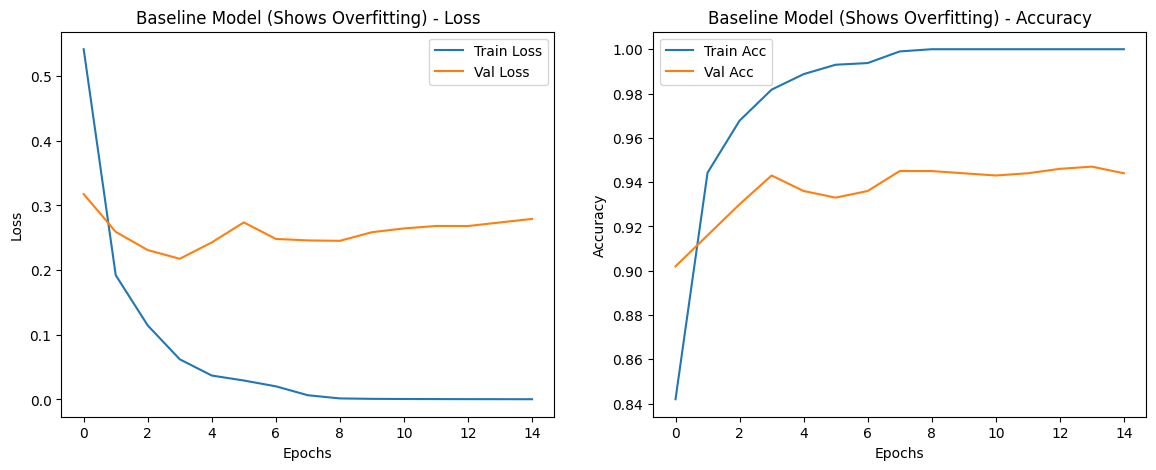

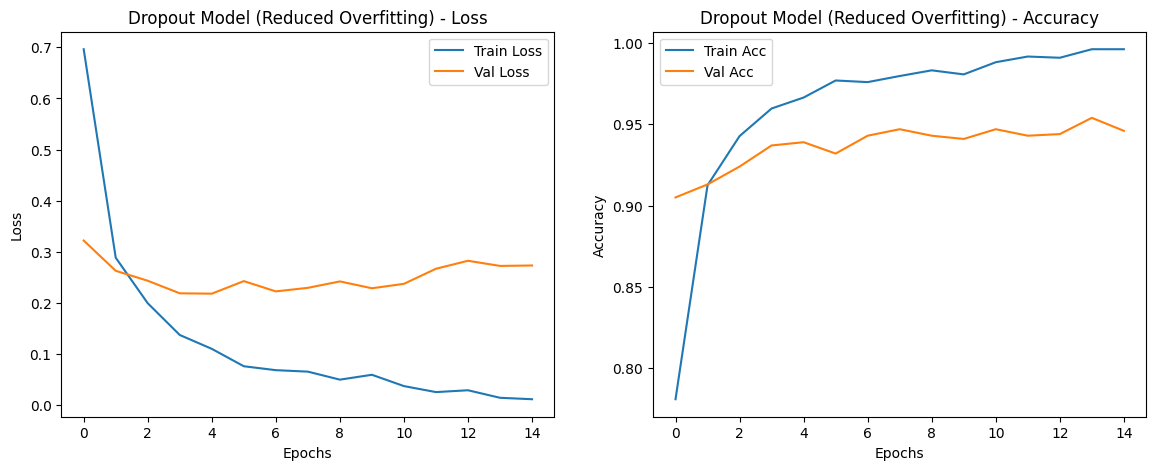

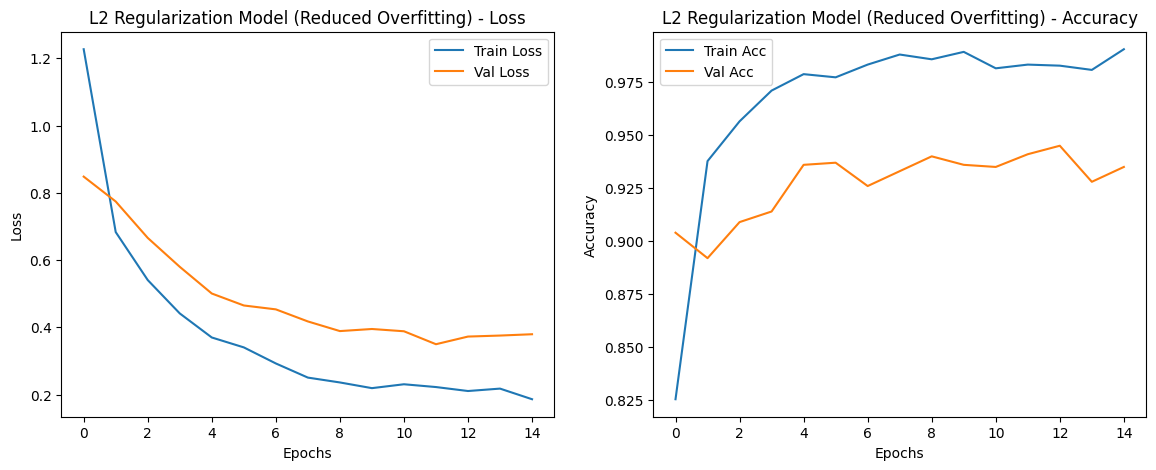

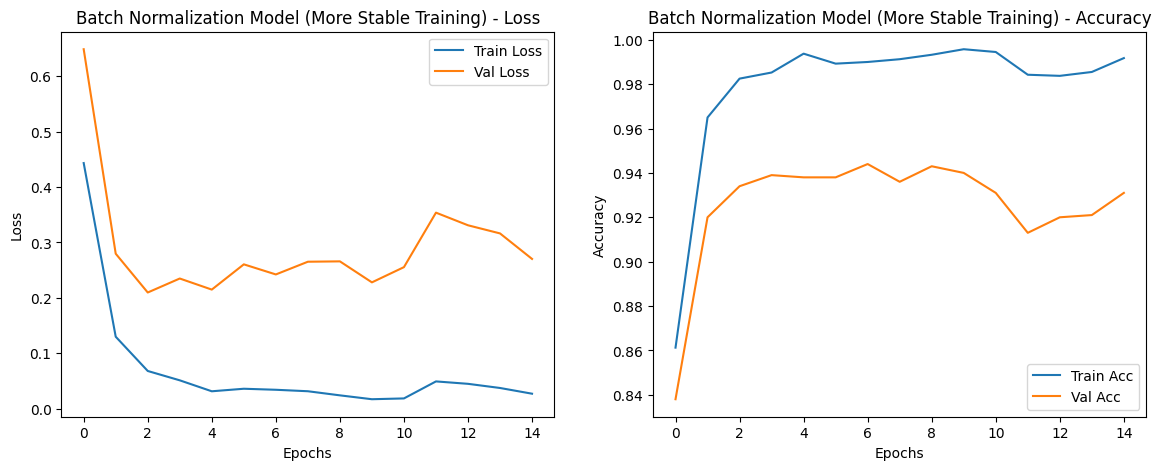

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt


# ----------------------------
# Load and prepare dataset
# ----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Use a small subset to trigger overfitting
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]


# ----------------------------
# Helper function to plot curves
# ----------------------------
def plot_history(history, title):
    plt.figure(figsize=(14,5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label="Train Acc")
    plt.plot(history.history['val_accuracy'], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()



# ==========================================
# 1️⃣ BASELINE MODEL (Overfitting)
# ==========================================
baseline = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

baseline.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_base = baseline.fit(X_train_small, y_train_small,
                            epochs=15, batch_size=32,
                            validation_split=0.2, verbose=0)

plot_history(history_base, "Baseline Model (Shows Overfitting)")


# ==========================================
# 2️⃣ DROPOUT MODEL
# ==========================================
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = dropout_model.fit(X_train_small, y_train_small,
                                    epochs=15, batch_size=32,
                                    validation_split=0.2, verbose=0)

plot_history(history_dropout, "Dropout Model (Reduced Overfitting)")


# ==========================================
# 3️⃣ L2 REGULARIZATION MODEL
# ==========================================
l2_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

l2_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = l2_model.fit(X_train_small, y_train_small,
                          epochs=15, batch_size=32,
                          validation_split=0.2, verbose=0)

plot_history(history_l2, "L2 Regularization Model (Reduced Overfitting)")


# ==========================================
# 4️⃣ BATCH NORMALIZATION MODEL
# ==========================================
bn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

bn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_bn = bn_model.fit(X_train_small, y_train_small,
                          epochs=15, batch_size=32,
                          validation_split=0.2, verbose=0)

plot_history(history_bn, "Batch Normalization Model (More Stable Training)")